In [1]:
import torch
import time
import torch.nn as nn

from neuromancer.loggers import BasicLogger
import neuromancer.psl as psl
from neuromancer.system import Node, System
from neuromancer.constraint import variable
from neuromancer.loss import PenaltyLoss
from neuromancer.problem import Problem
from neuromancer.dynamics import ode, integrators

from SparseDPC.src.sindy.fx_library import fx_library , fx_policy_library
from SparseDPC.src.data.getdata import get_data, get_policy_data
from SparseDPC.src.trainer.trainer import SparseTrainer
torch.manual_seed(86)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")


In [2]:
# ground truth system model
gt_model = psl.nonautonomous.TwoTank()
# sampling rate
ts = gt_model.params[1]['ts']
# problem dimensions
nx = gt_model.nx    # number of states
nu = gt_model.nu    # number of control inputs
nref = nx           # number of references
# constraints bounds
umin = 0.
umax = 1.
xmin = 0.
xmax = 1



In [3]:
fx_models = [fx_library(i, nx=nx, nu=nu) for i in range(nx)]
for fx in fx_models:
    print(fx)

dx0/dt = 0.867*x0 + 0.226*x1 + 0.016*x0^2 + 0.352*x1^2 + 0.075*x0*x1 + 0.878*u_0 + 0.176*u_1 + 0.391*u_0*u_1 + 0.221*x0*u_0 + 0.574*x1*u_0 + 0.005*x0*u_1 + 0.131*x1*u_1 + 0.840*sqrt(x0) + 0.904*sqrt(x1) 

dx1/dt = 0.942*x1 + 0.940*x0 + 0.142*x1^2 + 0.163*x0^2 + 0.609*x1*x0 + 0.634*u_0 + 0.090*u_1 + 0.842*u_0*u_1 + 0.659*x1*u_0 + 0.506*x0*u_0 + 0.756*x1*u_1 + 0.357*x0*u_1 + 0.745*sqrt(x1) + 0.378*sqrt(x0) 



In [153]:
nsim = 2000   # number of simulation steps in the dataset
nsteps = 2  # number of prediction horizon steps in the loss function
bs = 100     # minibatching batch size
train_loader, dev_loader, test_data = get_data(gt_model, nsim, nsteps, ts, bs)

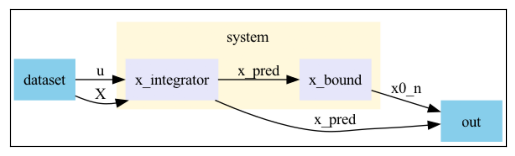

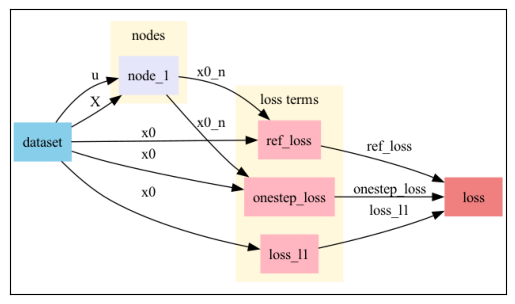

None
epoch: 0	train_loss: 1.80573	dev_loss: 1.54046	eltime:  1.36448
epoch: 100	train_loss: 0.01962	dev_loss: 0.02371	eltime:  5.71501
epoch: 200	train_loss: 0.00652	dev_loss: 0.01032	eltime:  10.22894
epoch: 300	train_loss: 0.00142	dev_loss: 0.00254	eltime:  14.80261
epoch: 400	train_loss: 0.00035	dev_loss: 0.00040	eltime:  19.27442
epoch: 500	train_loss: 0.00010	dev_loss: 0.00014	eltime:  23.49173
epoch: 600	train_loss: 0.00003	dev_loss: 0.00007	eltime:  27.93679
epoch: 700	train_loss: 0.00003	dev_loss: 0.00006	eltime:  32.19539

---------- Model 0 BEFORE pruning ----------
dx0/dt = 0.162*x0 + -0.282*x1 + -0.054*x0^2 + 0.192*x1^2 + -0.040*x0*x1 + 0.021*u_0 + -0.021*u_1 + 0.046*u_0*u_1 + -0.178*x0*u_0 + 0.202*x1*u_0 + -0.166*x0*u_1 + 0.102*x1*u_1 + -0.068*sqrt(x0) + 0.106*sqrt(x1) 

   Threshold=0.002  Active=14  (prev=14)
   Pruned terms: []

⇒ No change in active sets; coefficients kept.

---------- Model 0 AFTER pruning  ----------
dx0/dt = 0.162*x0 + -0.282*x1 + -0.054*x0^2 + 0.19

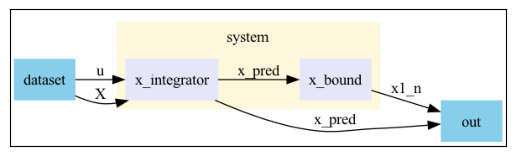

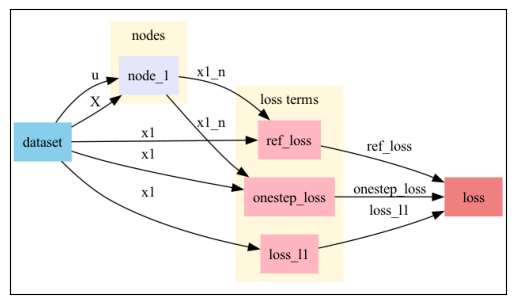

None
epoch: 0	train_loss: 1.17739	dev_loss: 1.26427	eltime:  0.87952
epoch: 100	train_loss: 0.00178	dev_loss: 0.00359	eltime:  3.73665
epoch: 200	train_loss: 0.00261	dev_loss: 0.00159	eltime:  6.62676
epoch: 300	train_loss: 0.00078	dev_loss: 0.00088	eltime:  9.39158
epoch: 400	train_loss: 0.00055	dev_loss: 0.00049	eltime:  12.03104
epoch: 500	train_loss: 0.00028	dev_loss: 0.00025	eltime:  14.67584
epoch: 600	train_loss: 0.00013	dev_loss: 0.00017	eltime:  17.32208
epoch: 700	train_loss: 0.00006	dev_loss: 0.00011	eltime:  19.96712

---------- Model 0 BEFORE pruning ----------
dx1/dt = 0.068*x1 + 0.280*x0 + -0.228*x1^2 + -0.222*x0^2 + 0.303*x1*x0 + 0.062*u_0 + -0.010*u_1 + 0.182*u_0*u_1 + -0.103*x1*u_0 + -0.191*x0*u_0 + 0.043*x1*u_1 + -0.183*x0*u_1 + -0.005*sqrt(x1) + -0.136*sqrt(x0) 

   Threshold=0.002  Active=14  (prev=14)
   Pruned terms: []

⇒ No change in active sets; coefficients kept.

---------- Model 0 AFTER pruning  ----------
dx1/dt = 0.068*x1 + 0.280*x0 + -0.228*x1^2 + -0.222

In [4]:
for i in range(nx):

    nsim = 2000   # number of simulation steps in the dataset
    nsteps = 2  # number of prediction horizon steps in the loss function
    bs = 100     # minibatching batch size
    train_loader, dev_loader, test_data = get_data(gt_model, nsim, nsteps, ts, bs)

    integrator_x = integrators.Euler(fx_models[i], h=ts)

    integrator_node_x = Node(integrator_x, ['X', 'u'], ['x_pred'], name="x_integrator")
    x_bound = Node(lambda x: torch.clamp(x, xmin, xmax)[:,i:i+1], ['x_pred'], [f'x{i}_n'], name="x_bound")
    dynamics_model_x = System([integrator_node_x, x_bound])
    dynamics_model_x.show()

    x = variable(f"x{i}")
    x_hat = variable(f'x{i}_n')[:, :-1, :]

    # Loss
    onestep_loss_x = 1.0 * ((x_hat[:, 1, :] == x[:, 1, :])^ 2)
    onestep_loss_x.name = "onestep_loss"

    reference_loss_x = 5. *((x_hat == x) ^ 2)
    reference_loss_x.name = "ref_loss"

    # Sparsity constraint
    l1_x = variable([x], lambda x: torch.norm(list(fx_models[i].parameters())[0], p=1))
    loss_l1_x = 0.000001 * (l1_x == 0)
    loss_l1_x.name = "loss_l1"

    objectives_x = [reference_loss_x, onestep_loss_x, loss_l1_x]
    loss_x = PenaltyLoss(objectives_x, [])
    problem_x = Problem([dynamics_model_x], loss_x)
    problem_x.show()

    lr = 1e-3
    optimizer_x = torch.optim.AdamW(problem_x.parameters(), lr=lr)

    logger = BasicLogger(args=None, savedir='test', verbosity=100,
                    stdout=['dev_loss', 'train_loss'])
    epochs=7500


    # trainer_x = SparseDynamicsTrainer(
    # problem_x,
    # fx_models[i],
    # lr,
    # None,
    # None,
    # optimizer=optimizer_x,
    # epochs=epochs,
    # train_metric='train_loss',
    # eval_metric='dev_loss',
    # logger=logger,
    # device=device,
    # threshold=0.002,
    # prune_every=750,
    # warmup=300,
    # patience=50,
    # threshold_mult=1.07
    # )

    trainer_x = SparseTrainer(
        problem      = problem_x,
        fx_models  = [fx_models[i]],      # list of SINDy models
        lr           = 1e-3,
        train_data=None,
        test_data=None,
        optimizers=[optimizer_x],
        epochs=epochs,
        train_metric='train_loss',
        eval_metric='dev_loss',
        logger=logger,
        device=device,
        threshold=0.002,
        prune_every=750,
        warmup=300,
        patience=50,
        threshold_mult=1.07,
        )
    for _ in range(1):
        # print(f'************   training with {nsteps} steps   ************   ')

        # Regenerate data for the new `nsteps`
        train_loader, dev_loader, test_data = get_data(gt_model, nsim, nsteps, ts, bs)
        trainer_x.train_data, trainer_x.dev_data = train_loader, dev_loader
        trainer_x.problem = problem_x  # Keep the problem consistent

        # Train control policy
        best_model = trainer_x.train()


        trainer_x.model.load_state_dict(best_model)

        # Update step size
        nsteps *= 2
        # trainer.model.loss.objectives[2].weight *= 1.1
        dynamics_model_x.nsteps = nsteps



In [5]:
for fx in fx_models:
    print(fx)

dx0/dt = -0.039*sqrt(x0) + 0.078*u_0 + -0.078*u_0*u_1 

dx1/dt = -0.040*sqrt(x1) + 0.040*sqrt(x0) + 0.080*u_0*u_1 



In [396]:
# ------------------------------------------------------------------ #
# helper that makes "single-state" integrators without slicing
# ------------------------------------------------------------------ #
def euler_integrator(fx_list, h):

    def euler_step(x, u):
        dx = torch.zeros_like(x)
        for idx, fx in enumerate(fx_list):
            dx[:,idx:idx+1] = fx(x,u)
        return x + h * dx

    return euler_step

# ------------------------------------------------------------------ #
# build integrator & bound nodes
# ------------------------------------------------------------------ #
euler = euler_integrator(fx_models, ts)          # custom step
x_integrator_node= Node(euler,['xn', 'u'], ['xn'], name=f"x_integrator")


sindy_system = System(
    [x_integrator_node],
    nsteps=nsteps
)

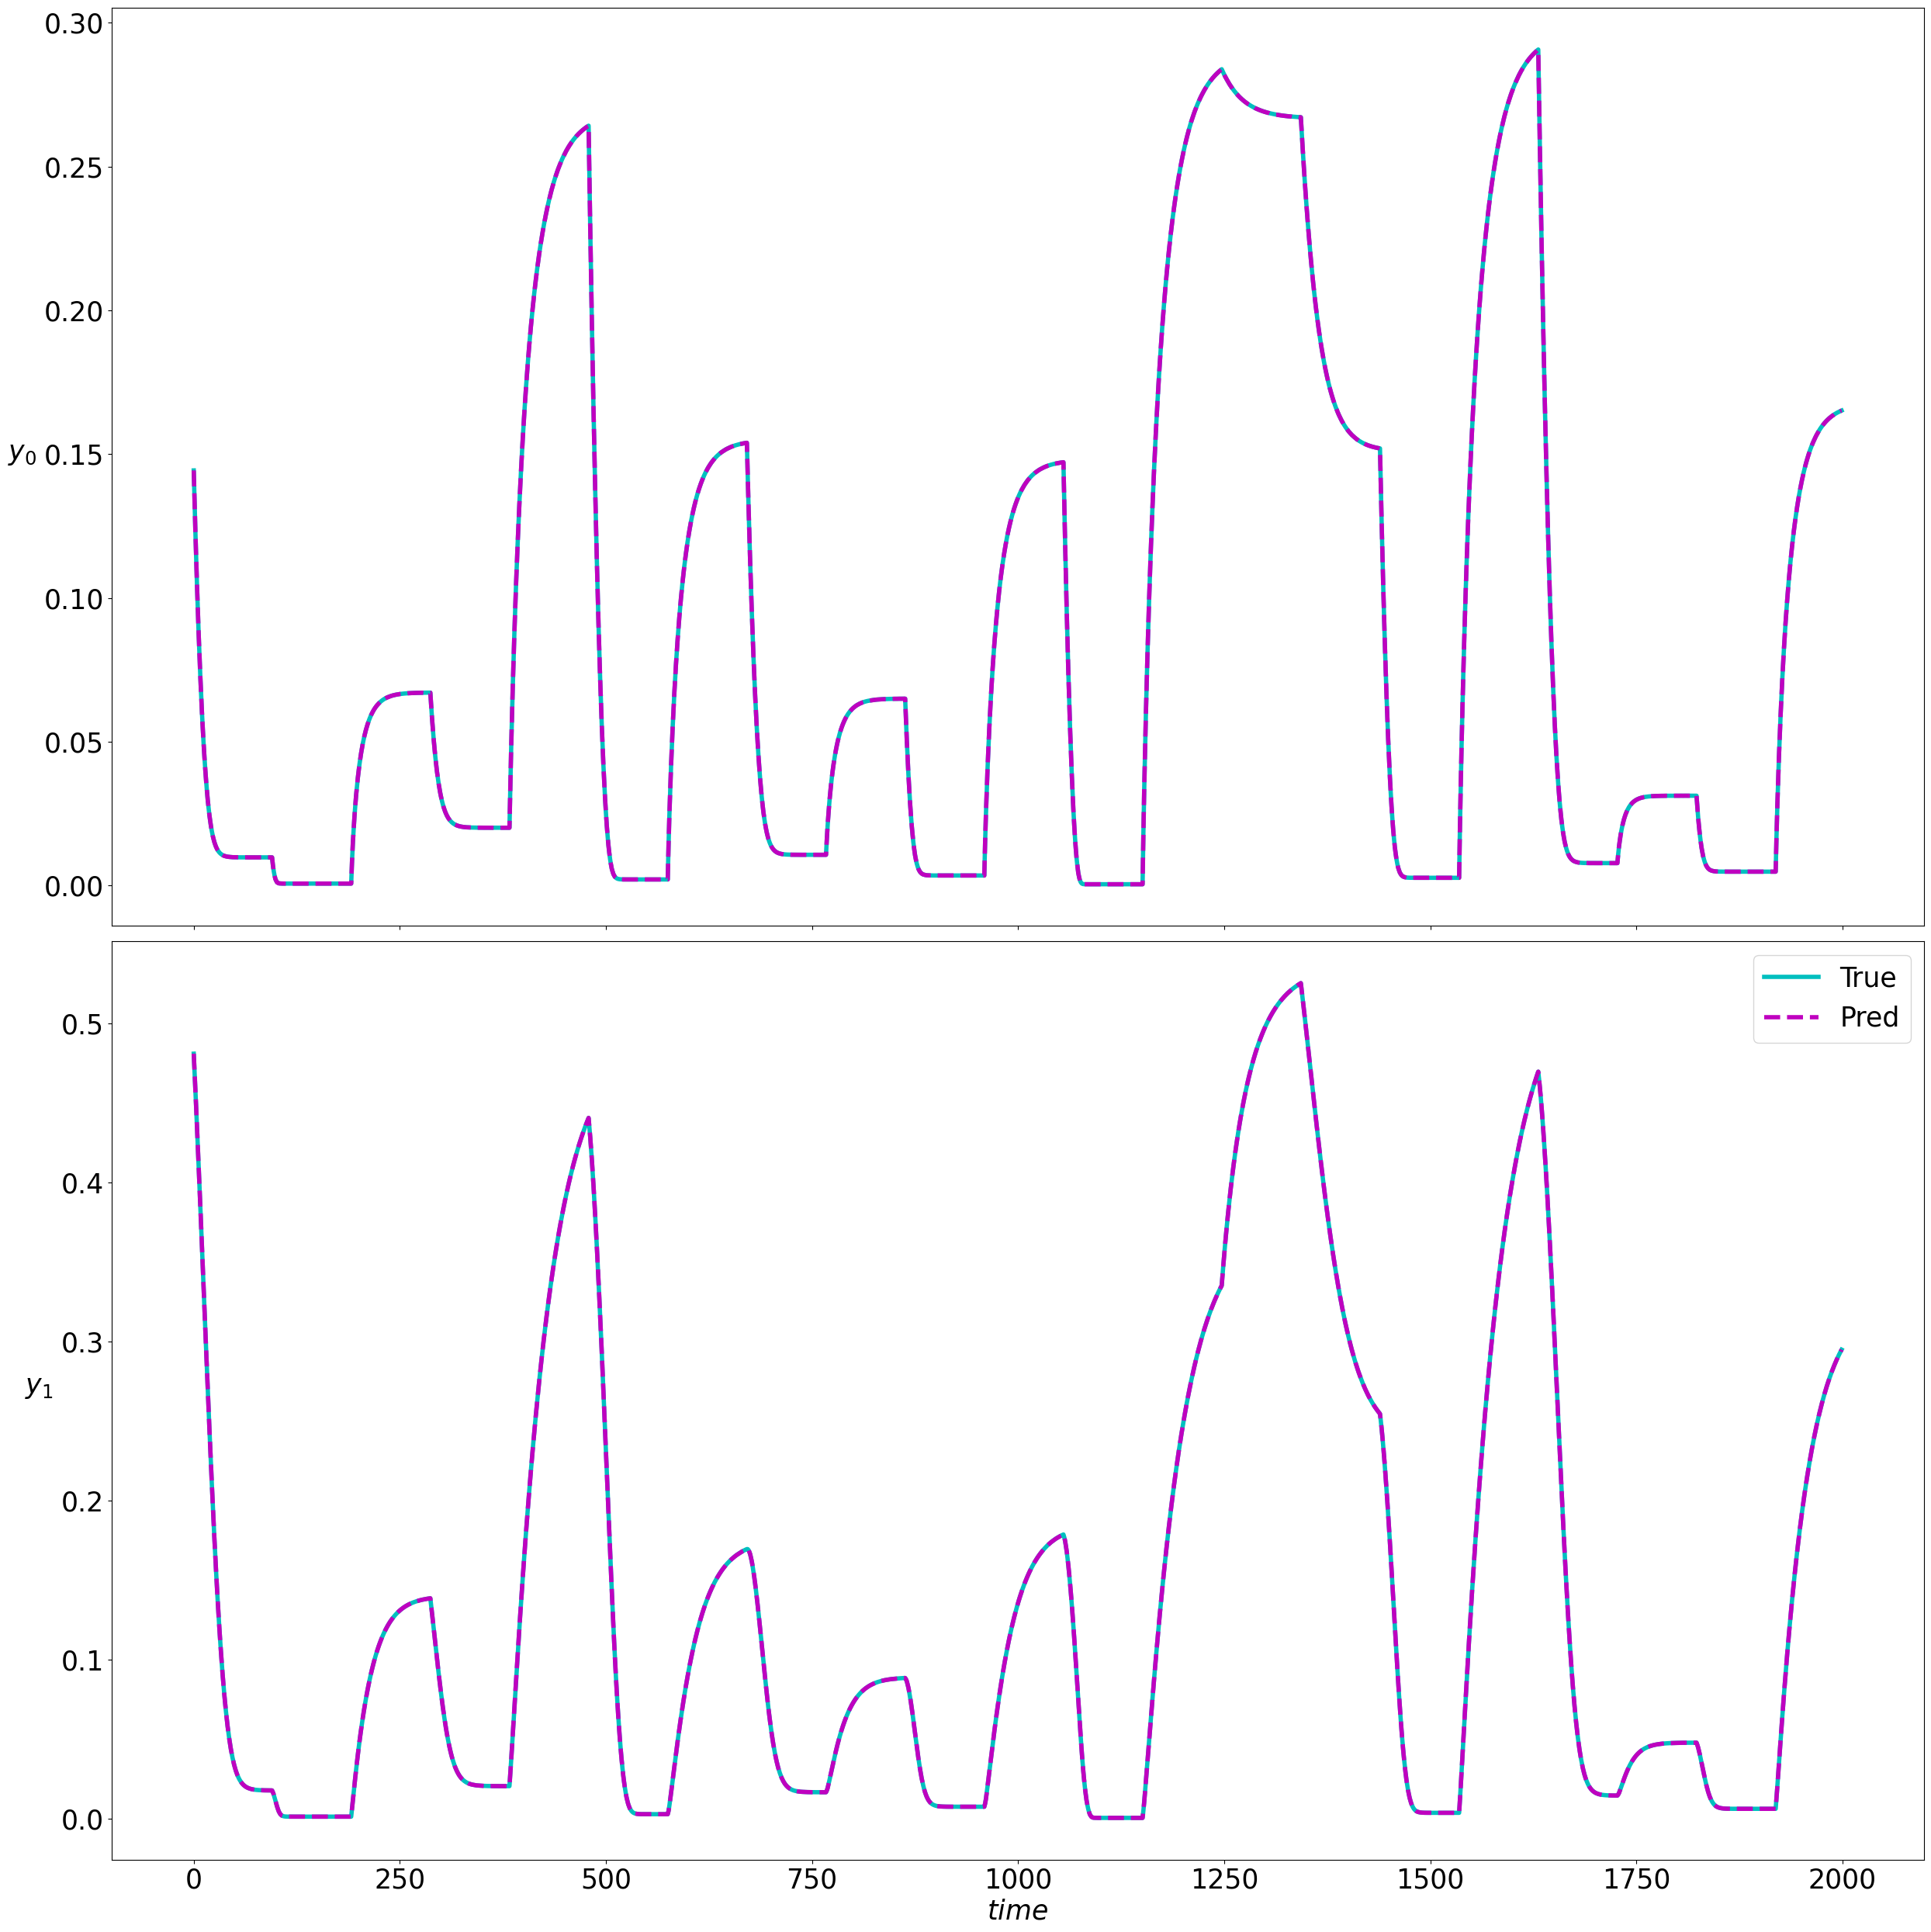

In [397]:
import matplotlib.pyplot as plt
sindy_system.nsteps = test_data['X'].shape[1]
test_output = sindy_system(test_data)

pred_traj = test_output['xn'][:, :-1, :]
true_traj = test_data['X']
pred_traj = pred_traj.detach().numpy().reshape(-1, nx)
true_traj = true_traj.detach().numpy().reshape(-1, nx)
pred_traj, true_traj = pred_traj.transpose(1, 0), true_traj.transpose(1, 0)

figsize = 25
fig, ax = plt.subplots(nx, figsize=(figsize, figsize))
labels = [f'$y_{k}$' for k in range(len(true_traj))]
for row, (t1, t2, label) in enumerate(zip(true_traj, pred_traj, labels)):
    if nx > 1:
        axe = ax[row]
    else:
        axe = ax
    axe.set_ylabel(label, rotation=0, labelpad=20, fontsize=figsize)
    axe.plot(t1, 'c', linewidth=4.0, label='True')
    axe.plot(t2, 'm--', linewidth=4.0, label='Pred')
    axe.tick_params(labelbottom=False, labelsize=figsize)
axe.tick_params(labelbottom=True, labelsize=figsize)
axe.legend(fontsize=figsize)
axe.set_xlabel('$time$', fontsize=figsize)
plt.tight_layout()

#### Policy Training

In [371]:
import importlib
import SparseDPC.src.sindy.sindy  # Import the module itself
import SparseDPC.src.sindy.fx_library
import SparseDPC.src.data.getdata
import SparseDPC.src.trainer.trainer

importlib.reload(SparseDPC.src.sindy.fx_library )  # Reload the module
importlib.reload(SparseDPC.src.sindy.sindy )
importlib.reload(SparseDPC.src.data.getdata)
importlib.reload(SparseDPC.src.trainer.trainer)

from SparseDPC.src.sindy.sindy import SINDy
from SparseDPC.src.sindy.fx_library import fx_library , fx_policy_library
from SparseDPC.src.data.getdata import get_data, get_policy_data
from SparseDPC.src.trainer.trainer import SparseTrainer

In [378]:
nsteps = 50  # prediction horizon
n_samples = 2500    # number of sampled scenarios
train_loader, dev_loader = get_policy_data(nsteps=nsteps,
                                           n_samples=n_samples,
                                           nx=nx,
                                           same_ref_for_all_states=True,
                                           device=device,
                                           batch_size=200,
                                           seed=5
                                           )

In [383]:
nsteps=50
policies_seed = 5
fx_policies = [fx_policy_library(nx=2, nref=1, policy_name= "p", seed=policies_seed),
               fx_policy_library(nx=2, nref=1, policy_name= "v", seed=policies_seed)]

for fp in fx_policies:
    print(fp)

p = 0.330*x_0 + -0.374*x_1 + 0.407*sin(x_0) + 0.320*sin(x_1) + 0.420*cos(x_0) + -0.383*cos(x_1) + -0.336*sin(2*x_0) + 0.238*sin(2*x_1) + -0.467*cos(2*x_0) + 0.494*cos(2*x_1) + 0.106*x_0*sin(x_0) + 0.065*x_1*sin(x_1) + -0.428*x_0*cos(x_0) + 0.159*x_1*cos(x_1) + 0.215*x_0 * x_1 + 0.079*r_0 + 0.481*cos(r_0) + 0.150*sin(r_0) + -0.443*cos(2*r_0) + 0.420*sin(2*r_0) + 0.170*x_0 * r_0 + -0.239*x_1 * r_0 + -0.459*x_0^2 * r_0 + 0.285*x_1^2 * r_0 + 0.475*x_0 * r_0^2 + -0.410*x_1 * r_0^2 

v = 0.330*x_0 + -0.374*x_1 + 0.407*sin(x_0) + 0.320*sin(x_1) + 0.420*cos(x_0) + -0.383*cos(x_1) + -0.336*sin(2*x_0) + 0.238*sin(2*x_1) + -0.467*cos(2*x_0) + 0.494*cos(2*x_1) + 0.106*x_0*sin(x_0) + 0.065*x_1*sin(x_1) + -0.428*x_0*cos(x_0) + 0.159*x_1*cos(x_1) + 0.215*x_0 * x_1 + 0.079*r_0 + 0.481*cos(r_0) + 0.150*sin(r_0) + -0.443*cos(2*r_0) + 0.420*sin(2*r_0) + 0.170*x_0 * r_0 + -0.239*x_1 * r_0 + -0.459*x_0^2 * r_0 + 0.285*x_1^2 * r_0 + 0.475*x_0 * r_0^2 + -0.410*x_1 * r_0^2 



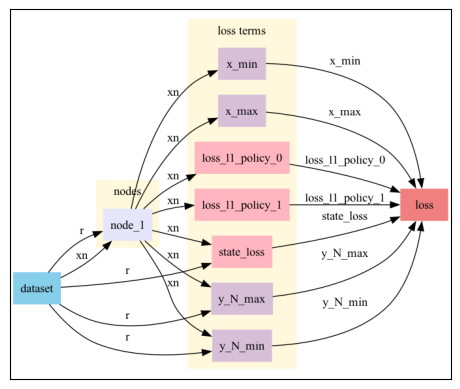

None
*** training with 50 steps ***
epoch: 0	train_loss: 1.06895	dev_loss: 1.29338	eltime:  1.83241
epoch: 10	train_loss: 0.33515	dev_loss: 0.41187	eltime:  21.91848
epoch: 20	train_loss: 0.29587	dev_loss: 0.36568	eltime:  42.91982
epoch: 30	train_loss: 0.27473	dev_loss: 0.34166	eltime:  64.20209
epoch: 40	train_loss: 0.26252	dev_loss: 0.32841	eltime:  85.45976
epoch: 50	train_loss: 0.25508	dev_loss: 0.31931	eltime:  106.21631
epoch: 60	train_loss: 0.24971	dev_loss: 0.31382	eltime:  127.13396
epoch: 70	train_loss: 0.24609	dev_loss: 0.30960	eltime:  147.70092
epoch: 80	train_loss: 0.24373	dev_loss: 0.30670	eltime:  168.55026
epoch: 90	train_loss: 0.24152	dev_loss: 0.30395	eltime:  189.11733

---------- Model 0 BEFORE pruning ----------
p = 0.104*x_0 + -0.531*x_1 + 0.196*sin(x_0) + 0.058*sin(x_1) + 0.360*cos(x_0) + -0.373*cos(x_1) + -0.328*sin(2*x_0) + -0.012*sin(2*x_1) + 0.067*cos(2*x_0) + 0.962*cos(2*x_1) + -0.360*x_0*sin(x_0) + -0.200*x_1*sin(x_1) + -0.448*x_0*cos(x_0) + -0.073*x_1*co

In [384]:
# ------------------------------------------------------------------ #
# 0.  Combined policy (any #policies)
# ------------------------------------------------------------------ #
policy_node = Node(
    lambda xn, r: torch.cat(
        [torch.clamp(fp(xn, r), umin, umax)  # capture fp by value
         for fp in fx_policies],
        dim=-1),
    ['xn', 'r'], ['u'],
    name="policy_combined"
)

# ------------------------------------------------------------------ #
# build integrator node and system
# ------------------------------------------------------------------ #

euler = euler_integrator(fx_models, ts)
x_integrator_node= Node(euler,['xn', 'u'], ['xn'], name=f"x_integrator")
sindy_system = System(
    [policy_node, x_integrator_node],
    nsteps=nsteps
)

# ------------------------------------------------------------------ #
# 4.  Objectives
# ------------------------------------------------------------------ #
x   = variable('xn')
ref = variable('r')

regulation_loss      = 5.0 * ((x == ref) ^ 2); regulation_loss.name = "state_loss"

#   L1 sparsity for each policy
loss_l1_policies = []
for idx, fp in enumerate(fx_policies):
    l1_raw  = variable([x],
                       lambda y, fp=fp: torch.norm(list(fp.parameters())[0], p=1),
                       display_name=f"l1_policy{idx}")
    l1_pen  = 0.001 * (l1_raw == 0)
    l1_pen.name = f"loss_l1_policy_{idx}"
    loss_l1_policies.append(l1_pen)

# ------------------------------------------------------------------ #
# 5.  Constraints
# ------------------------------------------------------------------ #
state_lower  = 10.0 * (x > xmin);           state_lower.name  = "x_min"
state_upper  = 10.0 * (x < xmax);           state_upper.name  = "x_max"
term_lower   = 10.0 * (x[:, [-1], :] > ref - 0.01); term_lower.name = "y_N_min"
term_upper   = 10.0 * (x[:, [-1], :] < ref + 0.01); term_upper.name = "y_N_max"

# ------------------------------------------------------------------ #
# 6.  Problem definition
# ------------------------------------------------------------------ #
objectives  = [regulation_loss, *loss_l1_policies]
constraints = [state_lower, state_upper, term_lower, term_upper]

loss     = PenaltyLoss(objectives, constraints)
problem  = Problem([sindy_system], loss)
problem.show()

# ------------------------------------------------------------------ #
# 7.  Optimiser & trainer
# ------------------------------------------------------------------ #
lr         = 0.008
optimizers = [torch.optim.AdamW(fp.parameters(), lr=lr) for fp in fx_policies]

trainer_policy = SparseTrainer(
    problem     = problem,
    fx_models   = fx_policies,
    lr          = lr,
    train_data  = train_loader,
    dev_data    = dev_loader,
    optimizers  = optimizers,
    epochs      = 1200,
    train_metric='train_loss',
    eval_metric ='dev_loss',
    logger      = BasicLogger(args=None, savedir='test', verbosity=10,
                              stdout=['dev_loss', 'train_loss']),
    device      = device,
    threshold   = 0.20,
    prune_every = 100,
    threshold_mult=1.11
)

print(f"*** training with {nsteps} steps ***")
best_state = trainer_policy.train()
trainer_policy.model.load_state_dict(best_state)

for i, fp in enumerate(fx_policies):
    print(f"Policy {i}:\n{fp}\n")


In [385]:
for fp in fx_policies:
    print(fp)

p = -1.748*x_1 + -0.813*sin(2*x_0) + 1.908*cos(2*x_1) + -1.176*x_0*sin(x_0) + 1.477*r_0 + 0.554*sin(r_0) + -1.822*cos(2*r_0) + 1.278*sin(2*r_0) + 0.897*x_1^2 * r_0 

v = -1.557*cos(2*x_0) + 1.567*cos(2*x_1) 



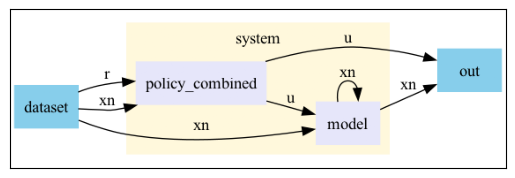

In [387]:
# white-box
# ODE model with no-plant model mismatch
two_tank = ode.TwoTankParam()                   # ODE system equations implemented in PyTorch
two_tank.c1 = nn.Parameter(torch.tensor(gt_model.c1), requires_grad=False)
two_tank.c2 = nn.Parameter(torch.tensor(gt_model.c2), requires_grad=False)
# integrate continuous time ODE
gt_integrator = integrators.Euler(two_tank, h=torch.tensor(ts))   # using 4th order runge kutta integrator
# symbolic system model
gt_integrator_node = Node(gt_integrator, ['xn', 'u'], ['xn'], name='model')

import copy
gt_sindy_policy = copy.deepcopy(System([policy_node,
                       gt_integrator_node]))
gt_sindy_policy.show()

(<Figure size 2000x1600 with 2 Axes>,
 array([[<Axes: xlabel='Time', ylabel='y'>],
        [<Axes: xlabel='Time', ylabel='u'>]], dtype=object))

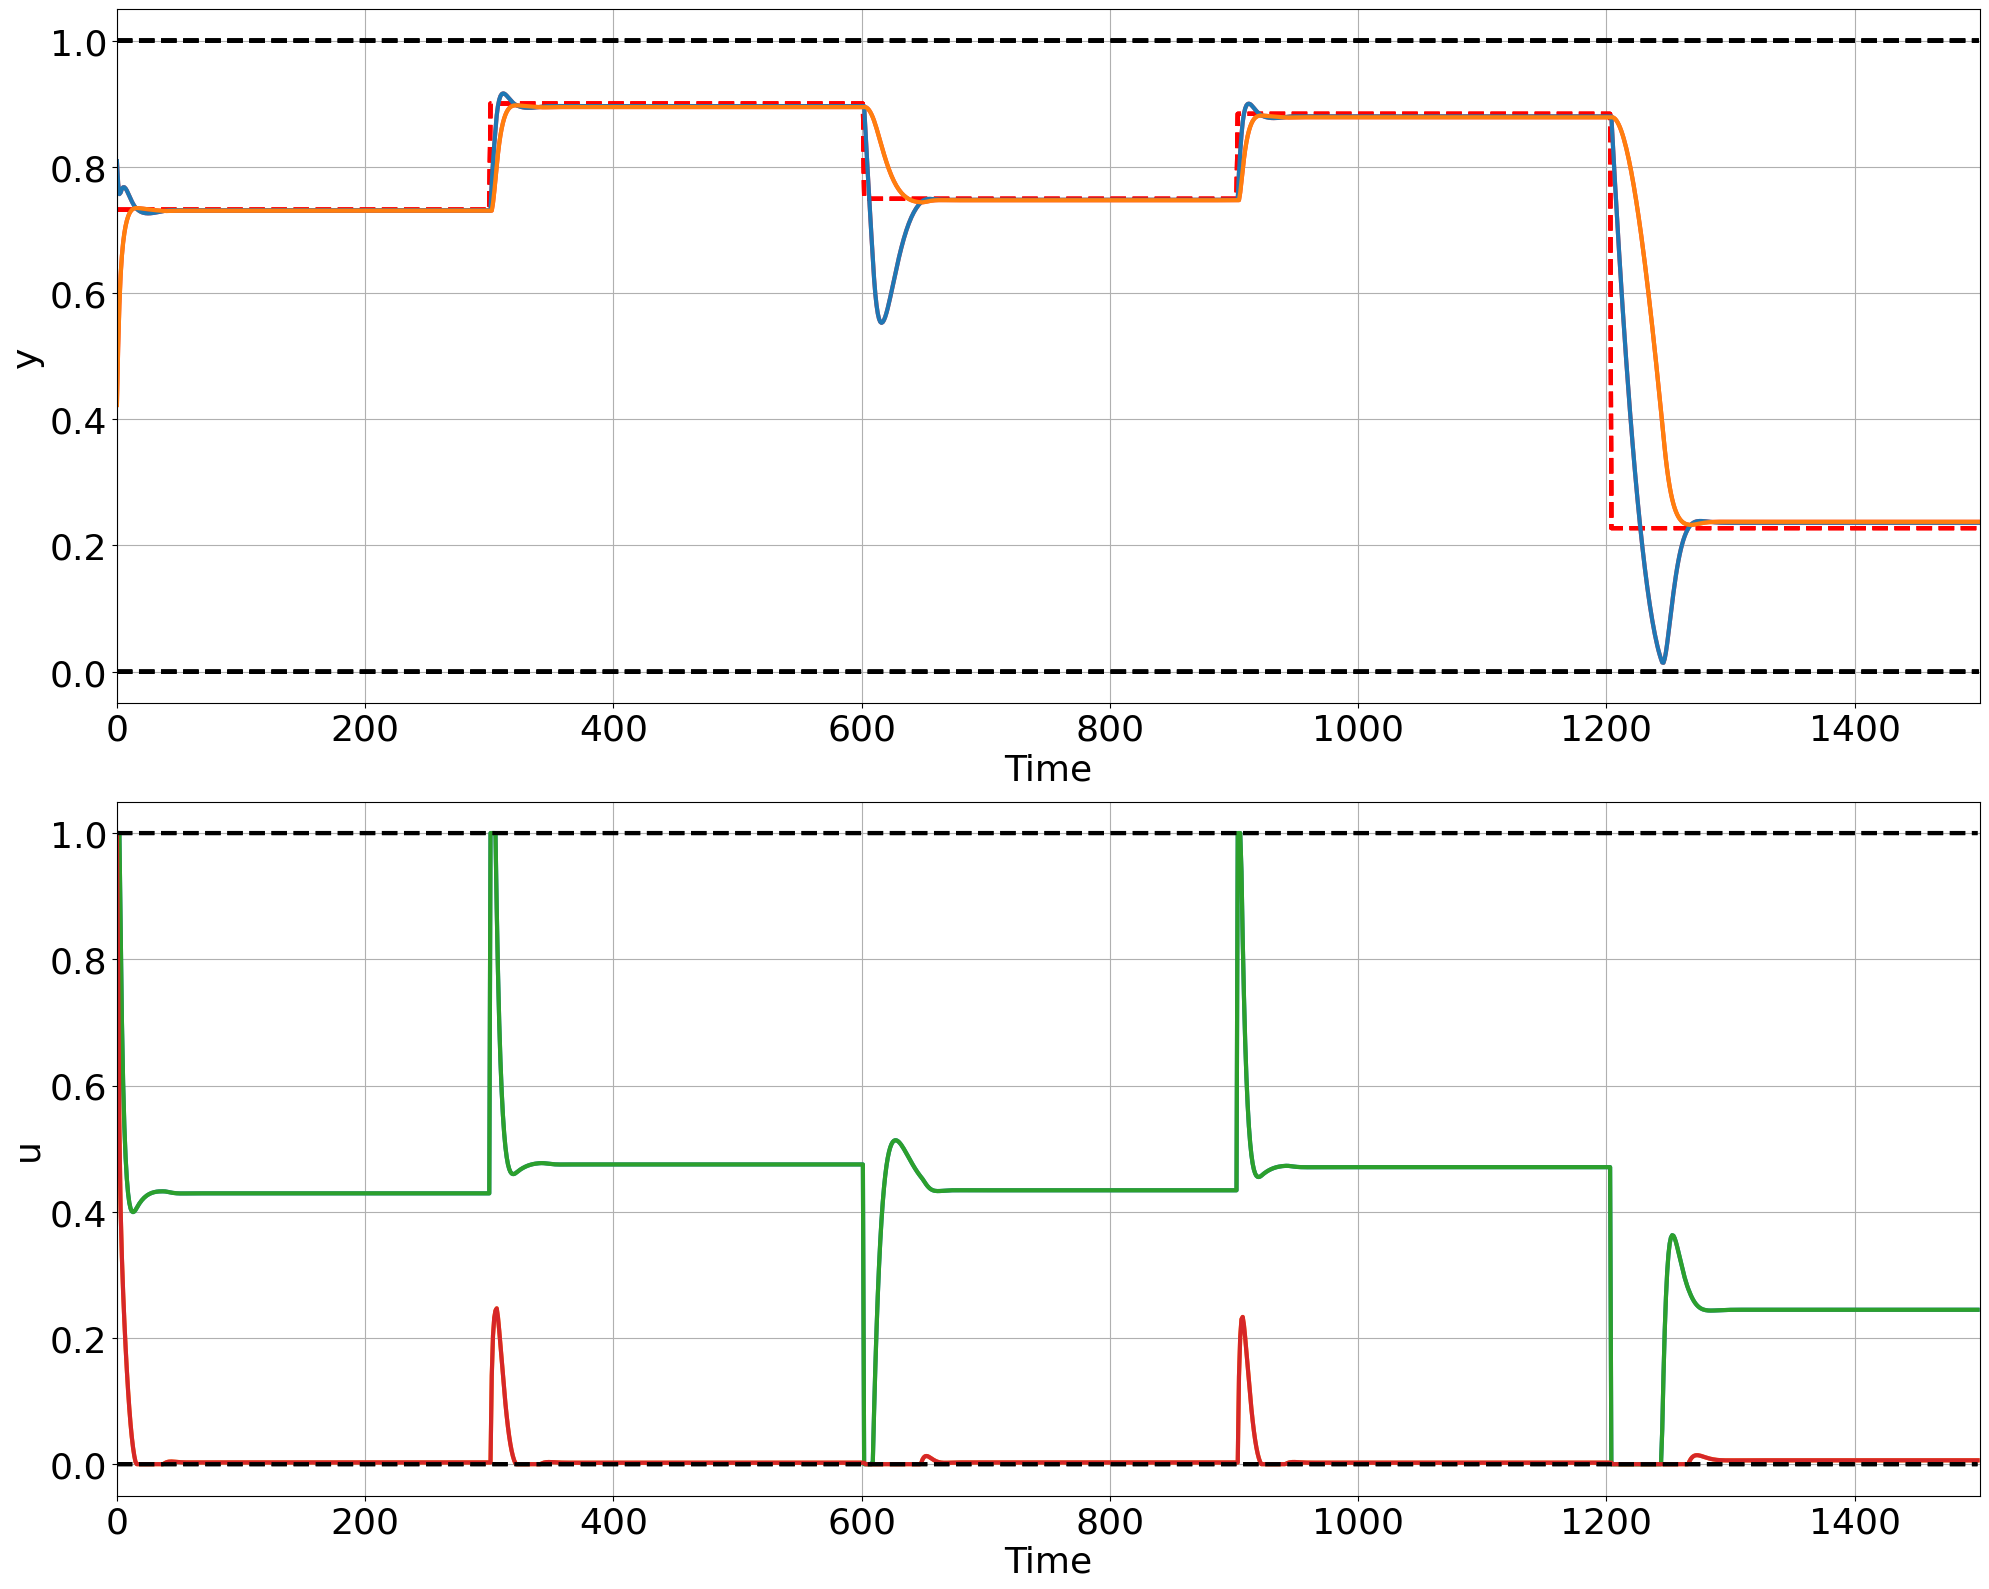

In [395]:
import numpy as np
from neuromancer.plot import pltCL, pltPhase

nsteps = 1500
torch.manual_seed(63)
seed = 84
rng = np.random.default_rng(seed)
# generate reference
np_refs = psl.signals.step(nsteps+1, 1, min=xmin, max=xmax, randsteps=5, rng=rng)
R = torch.tensor(np_refs, dtype=torch.float32).reshape(1, nsteps+1, 1)
torch_ref = torch.cat([R, R], dim=-1)
x_sample = torch.rand(1, 1, nx, dtype=torch.float32)
data = {'xn': x_sample,
        'x0_n': x_sample[:,:,0:1],
        'x1_n': x_sample[:,:,1:2],
        'r': torch_ref}

sindy_system.nsteps = nsteps
# perform closed-loop simulation
trajectories = sindy_system(data)

# constraints bounds
Umin = umin * np.ones([nsteps, nu])
Umax = umax * np.ones([nsteps, nu])
Xmin = xmin * np.ones([nsteps+1, nx])
Xmax = xmax * np.ones([nsteps+1, nx])
# plot closed loop trajectories
pltCL(Y=trajectories['xn'].detach().reshape(nsteps + 1, nx),
      R=trajectories['r'].detach().reshape(nsteps + 1, nref),
      U=trajectories['u'].detach().reshape(nsteps, nu),
      Umin=Umin, Umax=Umax, Ymin=Xmin, Ymax=Xmax)

### Sparse Policy with Whitebox model

In [389]:
nsteps=50
fx_policies_wb = [fx_policy_library(nx=2, nref=1, policy_name= "p", seed=policies_seed),
               fx_policy_library(nx=2, nref=1, policy_name= "v", seed=policies_seed)]

for fp in fx_policies_wb:
    print(fp)

p = 0.330*x_0 + -0.374*x_1 + 0.407*sin(x_0) + 0.320*sin(x_1) + 0.420*cos(x_0) + -0.383*cos(x_1) + -0.336*sin(2*x_0) + 0.238*sin(2*x_1) + -0.467*cos(2*x_0) + 0.494*cos(2*x_1) + 0.106*x_0*sin(x_0) + 0.065*x_1*sin(x_1) + -0.428*x_0*cos(x_0) + 0.159*x_1*cos(x_1) + 0.215*x_0 * x_1 + 0.079*r_0 + 0.481*cos(r_0) + 0.150*sin(r_0) + -0.443*cos(2*r_0) + 0.420*sin(2*r_0) + 0.170*x_0 * r_0 + -0.239*x_1 * r_0 + -0.459*x_0^2 * r_0 + 0.285*x_1^2 * r_0 + 0.475*x_0 * r_0^2 + -0.410*x_1 * r_0^2 

v = 0.330*x_0 + -0.374*x_1 + 0.407*sin(x_0) + 0.320*sin(x_1) + 0.420*cos(x_0) + -0.383*cos(x_1) + -0.336*sin(2*x_0) + 0.238*sin(2*x_1) + -0.467*cos(2*x_0) + 0.494*cos(2*x_1) + 0.106*x_0*sin(x_0) + 0.065*x_1*sin(x_1) + -0.428*x_0*cos(x_0) + 0.159*x_1*cos(x_1) + 0.215*x_0 * x_1 + 0.079*r_0 + 0.481*cos(r_0) + 0.150*sin(r_0) + -0.443*cos(2*r_0) + 0.420*sin(2*r_0) + 0.170*x_0 * r_0 + -0.239*x_1 * r_0 + -0.459*x_0^2 * r_0 + 0.285*x_1^2 * r_0 + 0.475*x_0 * r_0^2 + -0.410*x_1 * r_0^2 



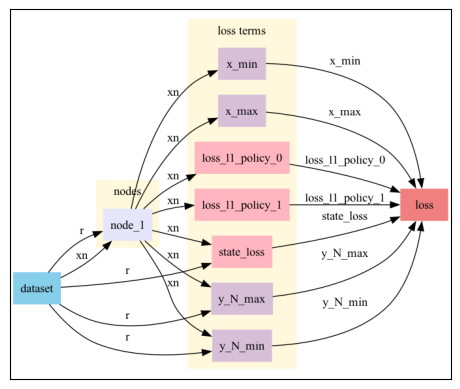

None
*** training with 50 steps ***
epoch: 0	train_loss: 0.93425	dev_loss: 1.15937	eltime:  1.80039
epoch: 10	train_loss: 0.32976	dev_loss: 0.40372	eltime:  18.53261
epoch: 20	train_loss: 0.28849	dev_loss: 0.35593	eltime:  37.77728
epoch: 30	train_loss: 0.26670	dev_loss: 0.33141	eltime:  56.33548
epoch: 40	train_loss: 0.25446	dev_loss: 0.31717	eltime:  75.91553
epoch: 50	train_loss: 0.24655	dev_loss: 0.30785	eltime:  95.17588
epoch: 60	train_loss: 0.24116	dev_loss: 0.30212	eltime:  114.84217
epoch: 70	train_loss: 0.23758	dev_loss: 0.29804	eltime:  134.17451
epoch: 80	train_loss: 0.23479	dev_loss: 0.29497	eltime:  154.55289
epoch: 90	train_loss: 0.23283	dev_loss: 0.29247	eltime:  174.53782

---------- Model 0 BEFORE pruning ----------
p = 0.106*x_0 + -0.527*x_1 + 0.199*sin(x_0) + 0.060*sin(x_1) + 0.359*cos(x_0) + -0.378*cos(x_1) + -0.321*sin(2*x_0) + -0.020*sin(2*x_1) + 0.057*cos(2*x_0) + 0.984*cos(2*x_1) + -0.372*x_0*sin(x_0) + -0.186*x_1*sin(x_1) + -0.442*x_0*cos(x_0) + -0.080*x_1*cos

In [390]:
# ------------------------------------------------------------------ #
# 0.  Combined policy (any #policies)
# ------------------------------------------------------------------ #
policy_node_wb = Node(
    lambda xn, r: torch.cat(
        [torch.clamp(fp(xn, r), umin, umax)  # capture fp by value
         for fp in fx_policies_wb],
        dim=-1),
    ['xn', 'r'], ['u'],
    name="policy_combined"
)


sindy_system_wb = System(
    [policy_node_wb, gt_integrator_node],
    nsteps=nsteps
)

# ------------------------------------------------------------------ #
# 4.  Objectives
# ------------------------------------------------------------------ #
x_wb   = variable('xn')
ref_wb = variable('r')

regulation_loss_wb      = 5.0 * ((x == ref) ^ 2); regulation_loss_wb.name = "state_loss"

#  L1 sparsity for each policy
loss_l1_policies = []
for idx, fp in enumerate(fx_policies_wb):
    l1_raw  = variable([x],
                       lambda y, fp=fp: torch.norm(list(fp.parameters())[0], p=1),
                       display_name=f"l1_policy{idx}")
    l1_pen  = 0.001 * (l1_raw == 0)
    l1_pen.name = f"loss_l1_policy_{idx}"
    loss_l1_policies.append(l1_pen)

# ------------------------------------------------------------------ #
# 5.  Constraints
# ------------------------------------------------------------------ #
state_lower  = 10.0 * (x > xmin);           state_lower.name  = "x_min"
state_upper  = 10.0 * (x < xmax);           state_upper.name  = "x_max"
term_lower   = 10.0 * (x[:, [-1], :] > ref - 0.01); term_lower.name = "y_N_min"
term_upper   = 10.0 * (x[:, [-1], :] < ref + 0.01); term_upper.name = "y_N_max"

# ------------------------------------------------------------------ #
# 6.  Problem definition
# ------------------------------------------------------------------ #
objectives  = [regulation_loss, *loss_l1_policies]
constraints = [state_lower, state_upper, term_lower, term_upper]

loss     = PenaltyLoss(objectives, constraints)
problem_wb  = Problem([sindy_system_wb], loss)
problem_wb.show()

# ------------------------------------------------------------------ #
# 7.  Optimiser & trainer
# ------------------------------------------------------------------ #
lr         = 0.008
optimizers_wb = [torch.optim.AdamW(fp.parameters(), lr=lr) for fp in fx_policies_wb]

trainer_policy_wb = SparseTrainer(
    problem     = problem_wb,
    fx_models   = fx_policies_wb,
    lr          = lr,
    train_data  = train_loader,
    dev_data    = dev_loader,
    optimizers  = optimizers_wb,
    epochs      = 1200,
    train_metric='train_loss',
    eval_metric ='dev_loss',
    logger      = BasicLogger(args=None, savedir='test', verbosity=10,
                              stdout=['dev_loss', 'train_loss']),
    device      = device,
    threshold   = 0.20,
    prune_every = 100,
    threshold_mult=1.11
)

print(f"*** training with {nsteps} steps ***")
best_state = trainer_policy_wb.train()
trainer_policy_wb.model.load_state_dict(best_state)

for i, fp in enumerate(fx_policies_wb):
    print(f"Policy {i}:\n{fp}\n")


(<Figure size 2000x1600 with 2 Axes>,
 array([[<Axes: xlabel='Time', ylabel='y'>],
        [<Axes: xlabel='Time', ylabel='u'>]], dtype=object))

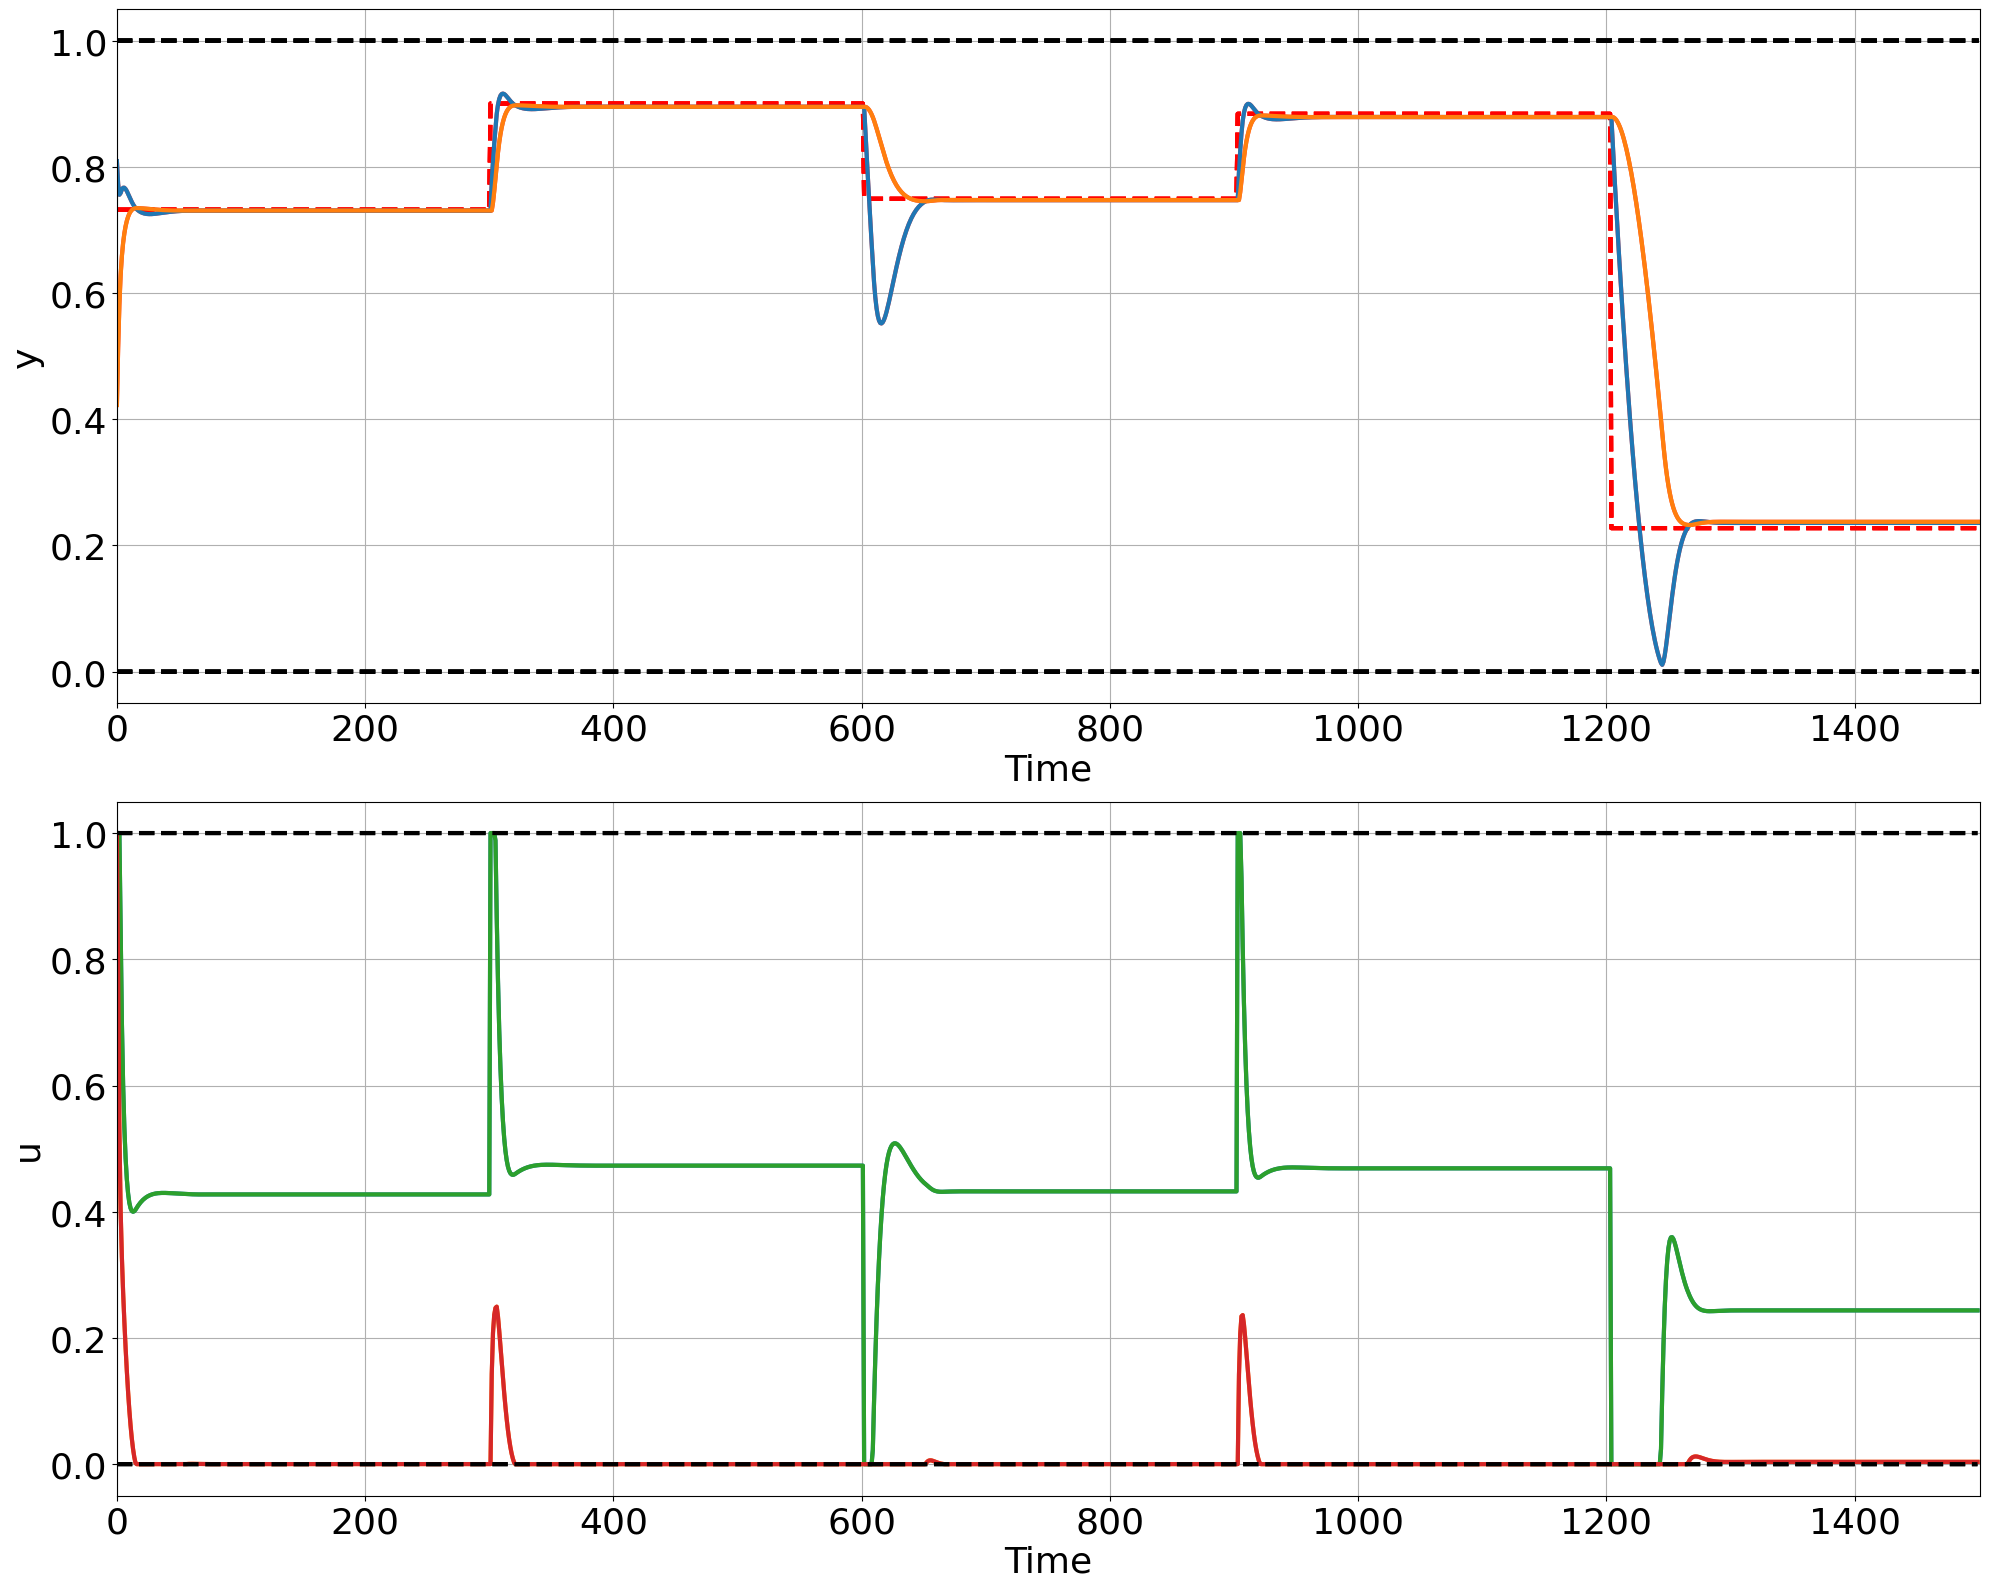

In [391]:
import numpy as np
from neuromancer.plot import pltCL, pltPhase

nsteps = 1500
torch.manual_seed(63)
seed = 84
rng = np.random.default_rng(seed)
# generate reference
np_refs = psl.signals.step(nsteps+1, 1, min=xmin, max=xmax, randsteps=5, rng=rng)
R = torch.tensor(np_refs, dtype=torch.float32).reshape(1, nsteps+1, 1)
torch_ref = torch.cat([R, R], dim=-1)
x_sample = torch.rand(1, 1, nx, dtype=torch.float32)
data = {'xn': x_sample,
        'x0_n': x_sample[:,:,0:1],
        'x1_n': x_sample[:,:,1:2],
        'r': torch_ref}

sindy_system_wb.nsteps = nsteps
# perform closed-loop simulation
trajectories = sindy_system_wb(data)

# constraints bounds
Umin = umin * np.ones([nsteps, nu])
Umax = umax * np.ones([nsteps, nu])
Xmin = xmin * np.ones([nsteps+1, nx])
Xmax = xmax * np.ones([nsteps+1, nx])
# plot closed loop trajectories
pltCL(Y=trajectories['xn'].detach().reshape(nsteps + 1, nx),
      R=trajectories['r'].detach().reshape(nsteps + 1, nref),
      U=trajectories['u'].detach().reshape(nsteps, nu),
      Umin=Umin, Umax=Umax, Ymin=Xmin, Ymax=Xmax)

In [392]:
for i, fp in enumerate(fx_policies):
    print(f"Policy {i}:\n{fp}\n")

Policy 0:
p = -1.748*x_1 + -0.813*sin(2*x_0) + 1.908*cos(2*x_1) + -1.176*x_0*sin(x_0) + 1.477*r_0 + 0.554*sin(r_0) + -1.822*cos(2*r_0) + 1.278*sin(2*r_0) + 0.897*x_1^2 * r_0 


Policy 1:
v = -1.557*cos(2*x_0) + 1.567*cos(2*x_1) 




In [393]:
for i, fp in enumerate(fx_policies_wb):
    print(f"Policy {i}:\n{fp}\n")

Policy 0:
p = -1.671*x_1 + -0.759*sin(2*x_0) + 1.879*cos(2*x_1) + -1.216*x_0*sin(x_0) + 1.293*r_0 + 0.961*sin(r_0) + -1.797*cos(2*r_0) + 1.078*sin(2*r_0) + 0.820*x_1^2 * r_0 


Policy 1:
v = -1.564*cos(2*x_0) + 1.571*cos(2*x_1) 


